In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import missingno as msno
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
from io import BytesIO
import requests

import seaborn as sns
from plotly.subplots import make_subplots

# dynamic chart
import ipywidgets as widgets
from ipywidgets import interact

In [33]:
df = pd.read_csv("eighteen_nineteen_university_datasets.csv",encoding="unicode_escape")
print(f"Dateset size :{df.shape}")
print("First 5 samples:")
display(df.head())
print("Last 5 samples:")
display(df.tail())
print("Features:")
for i in df.columns:
    print(i)

Dateset size :(1000, 12)
First 5 samples:


,World Rank,Institution,Location,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score
0,1,Harvard University,USA,1,2,1,1,1,1,1,1,100.0
1,2,Stanford University,USA,2,10,3,2,10,4,3,2,96.7
2,3,Massachusetts Institute of Technology,USA,3,3,11,3,30,15,2,6,95.1
3,4,University of Cambridge,United Kingdom,1,5,19,6,12,8,6,19,94.0
4,5,University of Oxford,United Kingdom,2,9,25,10,9,5,7,4,93.2


Last 5 samples:


,World Rank,Institution,Location,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score
995,996,Aga Khan University,Pakistan,3,-,> 1000,-,> 1000,> 1000,464,673,69.8
996,997,University of Calcutta,India,17,353,716,296,798,966,> 1000,> 1000,69.8
997,998,K?chi University,Japan,56,-,> 1000,-,> 1000,> 1000,811,673,69.8
998,999,Soonchunhyang University,South Korea,35,-,> 1000,-,881,> 1000,> 1000,898,69.8
999,1000,Capital Normal University,China,108,-,869,-,923,904,889,> 1000,69.8


Features:
World Rank
Institution
Location
National Rank
Quality of Education
Alumni Employment
Quality of Faculty
Research Output
Quality Publications
Influence
Citations
Score


Some university names such as sample 997 seem to have irrelevent characters (?) in them. But I do not need to fix them

<Figure size 1000x500 with 0 Axes>

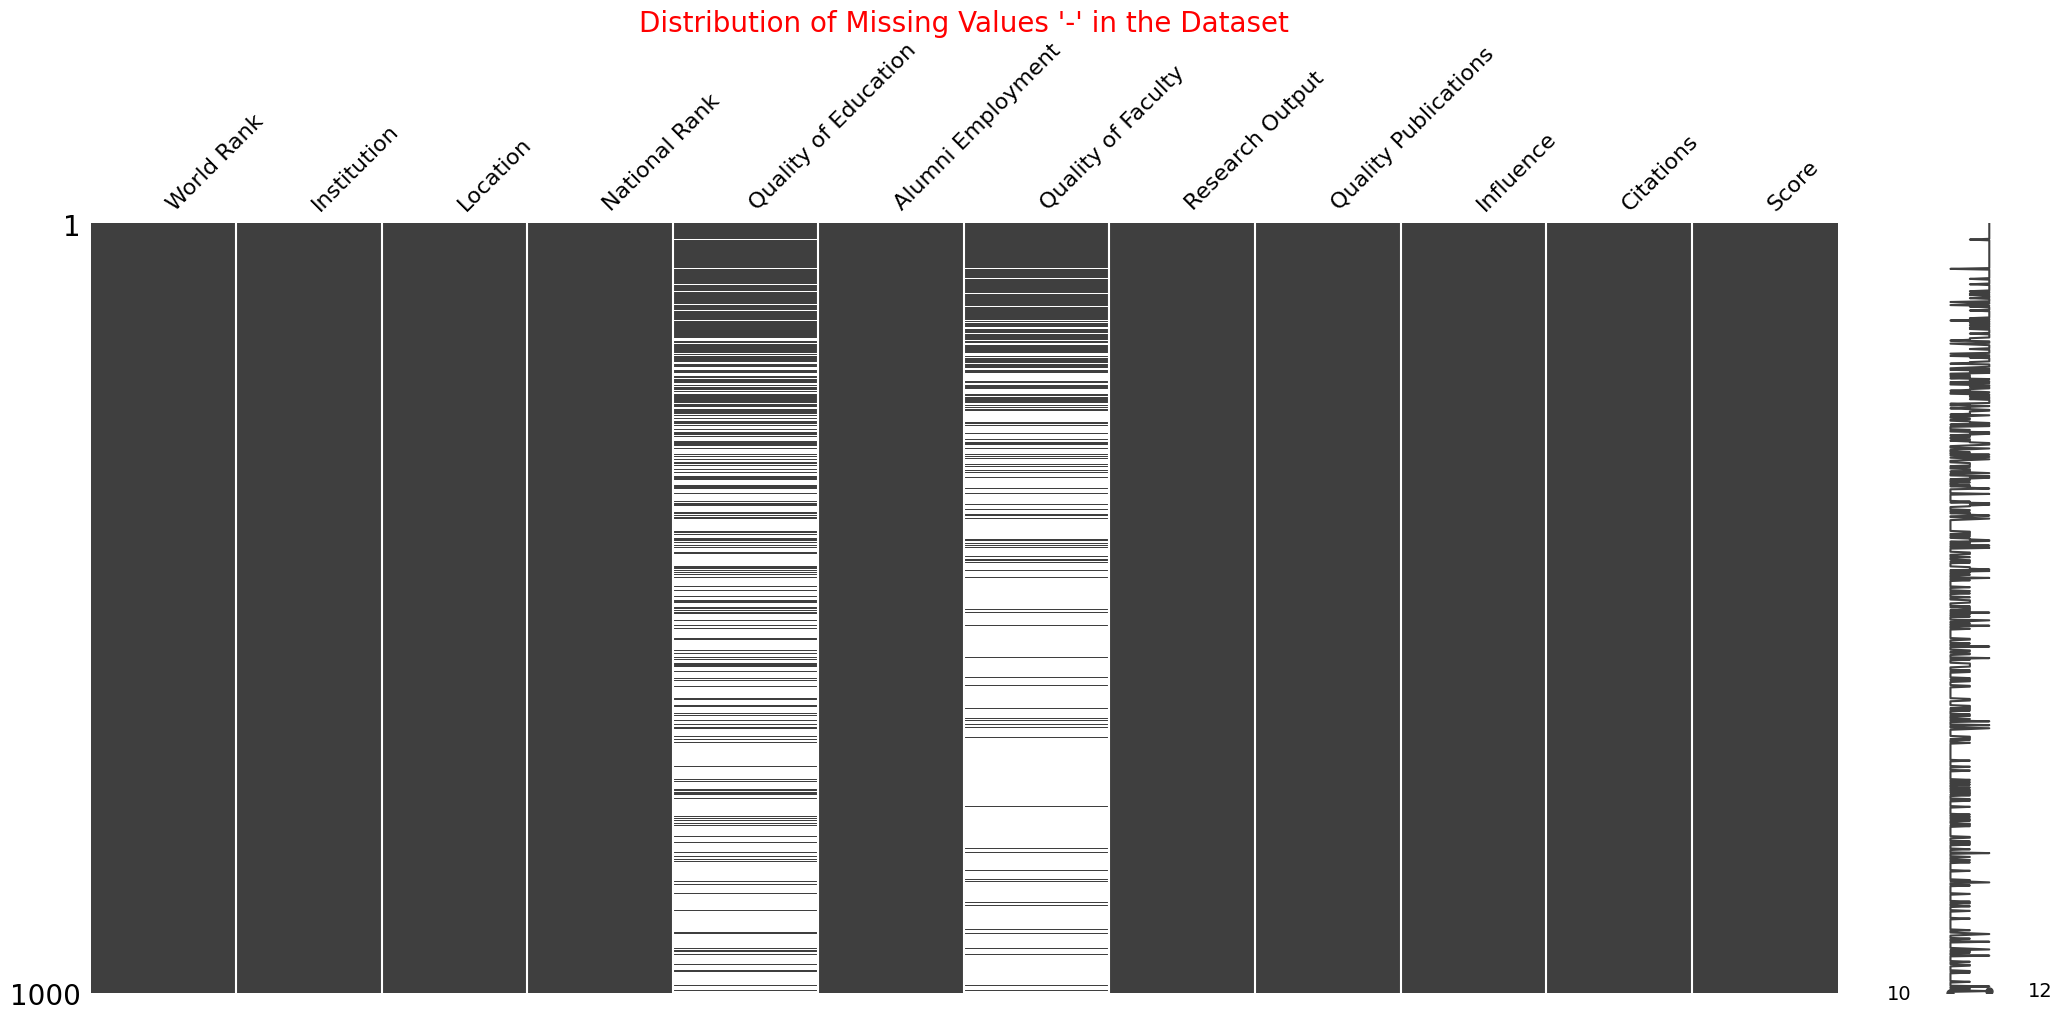

In [5]:
df1 = df.copy()
df1.replace("-", np.nan,inplace=True)
df1.tail()

plt.figure(figsize=(10, 5))
msno.matrix(df1)
plt.title("Distribution of Missing Values '-' in the Dataset",fontsize=20 , c="red")
plt.show()

<Figure size 1000x500 with 0 Axes>

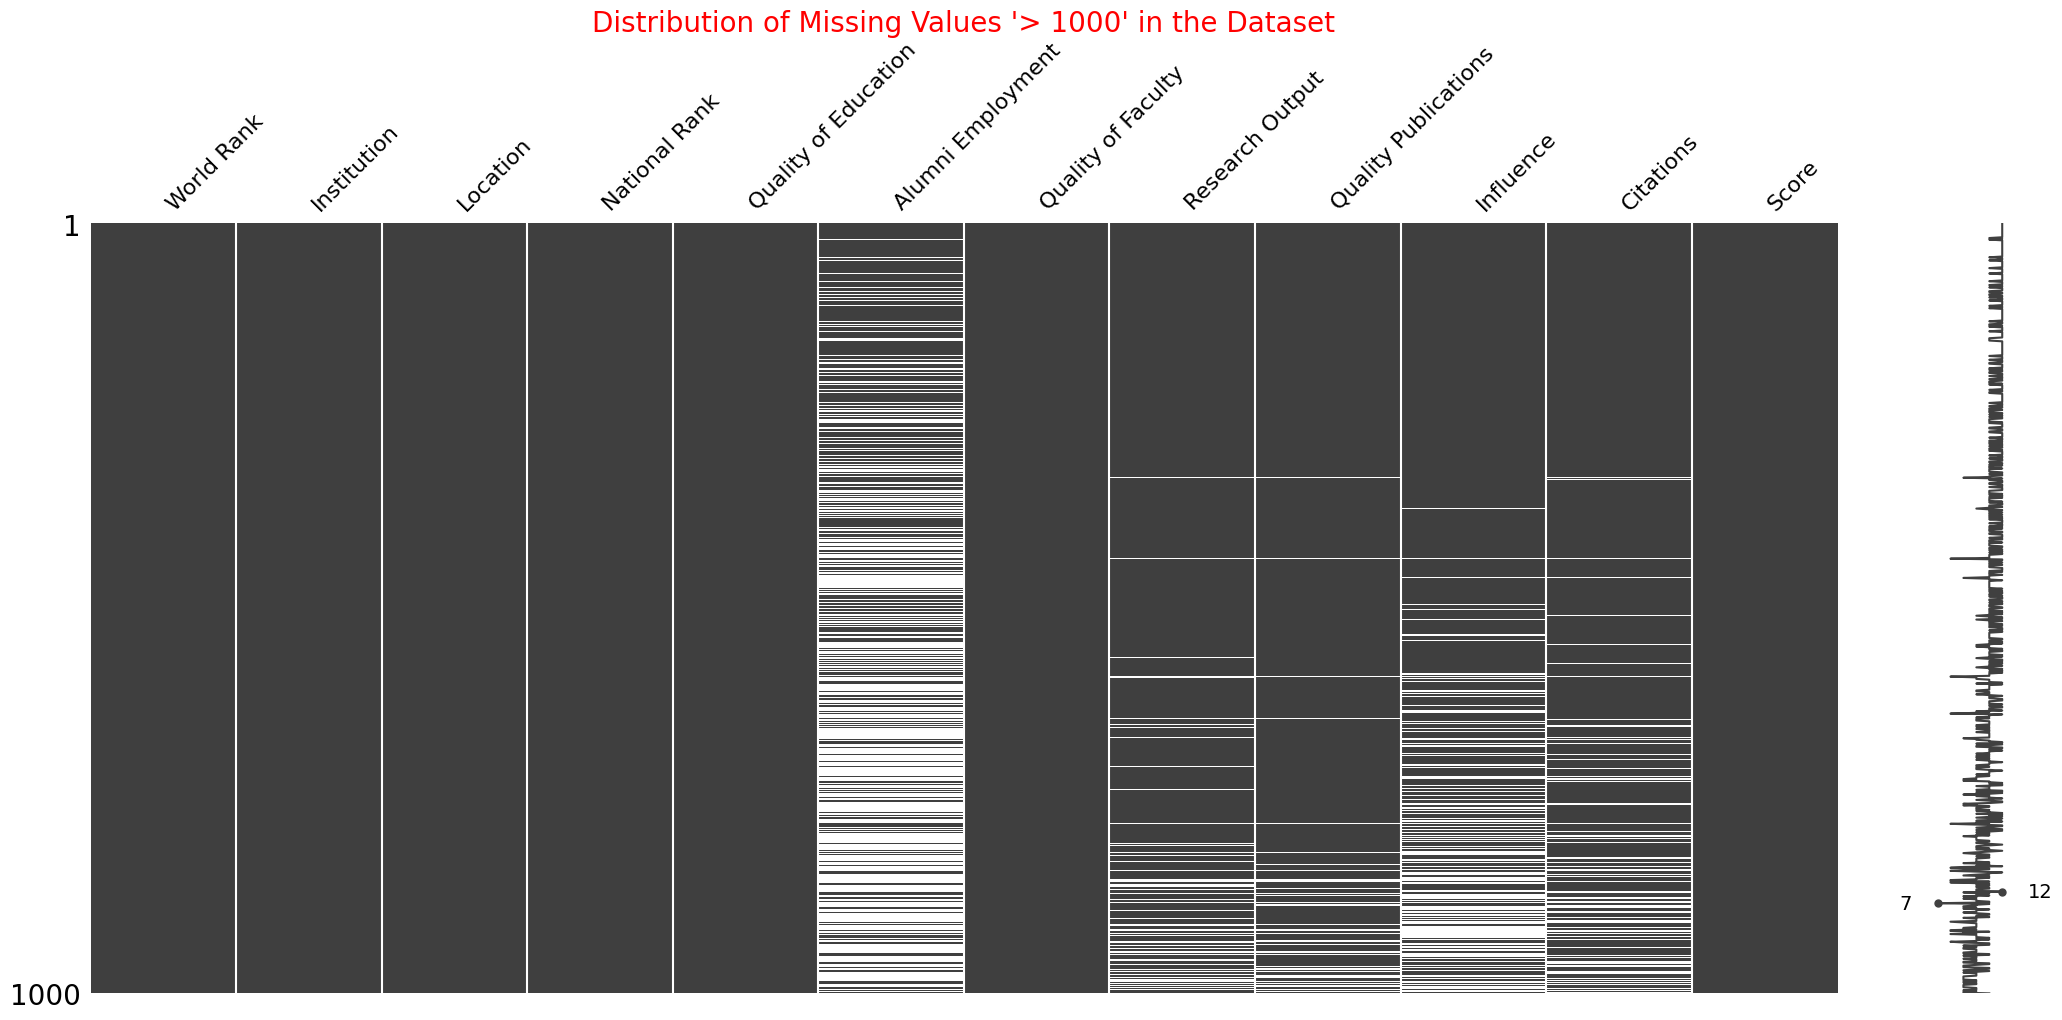

In [6]:
df2 = df.copy()
df2.replace("> 1000", np.nan,inplace=True)
df2.tail()

plt.figure(figsize=(10, 5))
msno.matrix(df2)
plt.title("Distribution of Missing Values '> 1000' in the Dataset",fontsize=20 , c="red")
plt.show()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   World Rank            1000 non-null   int64  
 1   Institution           1000 non-null   object 
 2   Location              1000 non-null   object 
 3   National Rank         1000 non-null   int64  
 4   Quality of Education  1000 non-null   object 
 5   Alumni Employment     1000 non-null   object 
 6   Quality of Faculty    1000 non-null   object 
 7   Research Output       1000 non-null   object 
 8   Quality Publications  1000 non-null   object 
 9   Influence             1000 non-null   object 
 10  Citations             1000 non-null   object 
 11  Score                 1000 non-null   float64
dtypes: float64(1), int64(2), object(9)
memory usage: 93.9+ KB


## Checking feautres one by one
### World rank
No duplicate, all type int

In [8]:
# How many unique values?
display(df["World Rank"].nunique())

# check dtypes
s = set()
for r in df["World Rank"]:
    s.add(type(r))
    
print(s)

1000

{<class 'int'>}


### Institution  
All are string, no duplicates.

In [9]:
# display(df["Institution"].unique())

# check for duplicates
if len(df["Institution"]) == len(set(df["Institution"])):
    print("No duplicates")
   
# check types 
temp = 0
for i in df["Institution"]:
    if not type(i) == str :
        temp += 1
        
print(temp) 

No duplicates
0


### Location  
All are strings, No anomaly value detected.

In [10]:
display(df["Location"].unique())

# check types 
temp = 0
for i in df["Location"]:
    if not type(i) == str :
        temp += 1
        
print(temp) 

array(['USA', 'United Kingdom', 'Japan', 'Canada', 'Switzerland',
       'France', 'Denmark', 'Israel', 'Germany', 'Sweden', 'Australia',
       'South Korea', 'Italy', 'Netherlands', 'Norway', 'Brazil', 'Spain',
       'China', 'Finland', 'Singapore', 'Belgium', 'Taiwan', 'Russia',
       'Hong Kong', 'Austria', 'Czech Republic', 'Portugal',
       'South Africa', 'Ireland', 'New Zealand', 'Mexico', 'Poland',
       'Argentina', 'Greece', 'Saudi Arabia', 'Chile', 'Serbia',
       'Slovenia', 'Iran', 'Hungary', 'India', 'Malaysia', 'Egypt',
       'Croatia', 'Thailand', 'Iceland', 'Estonia', 'Turkey',
       'Slovak Republic', 'Uruguay', 'Lithuania', 'Colombia', 'Uganda',
       'Lebanon', 'Pakistan', 'Romania', 'Bulgaria', 'Cyprus', 'Tunisia',
       'Nigeria', 'Macau'], dtype=object)

0


### National Rank

In [11]:
display(df["National Rank"].unique()) 
display(df["National Rank"].nunique())  # expect it to be less than sample size

# check dtypes
s = set()
for r in df["National Rank"]:
    s.add(type(r))
    
print(s)

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

213

{<class 'int'>}


### Quality of Education

- All are strings, they should be converted to int , no floats exists.
- "-" values need to be fixed.


In [12]:
l = []
t= 0
w = 0
for i in df["Quality\xa0of Education"]:
    if not type(i)== int:
        l.append(i)
    if type(i) == str:
        t += 1
    try:
        if float(i) != int(i):
            w +=1
    except:
        pass

print(l)
print(f"There are {t} strings") 
print(f"number of strings showing float numbers : {w}")


['2', '10', '3', '5', '9', '7', '4', '16', '1', '13', '11', '17', '31', '14', '58', '24', '86', '47', '75', '37', '32', '-', '129', '98', '64', '25', '65', '29', '46', '93', '108', '40', '205', '61', '131', '206', '68', '173', '302', '165', '212', '83', '374', '171', '8', '71', '103', '91', '162', '134', '215', '166', '70', '49', '35', '572', '232', '95', '264', '-', '19', '472', '96', '148', '186', '33', '117', '43', '267', '149', '231', '122', '187', '310', '97', '15', '583', '625', '271', '-', '112', '188', '169', '192', '105', '102', '386', '589', '-', '228', '34', '340', '109', '-', '294', '281', '334', '586', '142', '363', '570', '400', '-', '311', '73', '-', '-', '183', '140', '486', '343', '89', '69', '-', '123', '85', '6', '317', '399', '82', '339', '48', '175', '455', '594', '23', '-', '373', '67', '172', '338', '94', '-', '292', '113', '619', '603', '401', '282', '303', '565', '60', '237', '209', '273', '144', '79', '384', '220', '553', '-', '-', '-', '100', '80', '266', '-'

### Alumni Employment
- String values that need to be converted to int
- "> 1000" exist in 509 samples. They should be fixed.

In [13]:
display(df["Alumni Employment"])
# display(df["Alumni Employment"].unique())

display(df["Alumni Employment"].value_counts().sort_index())

# check types 
temp = 0
for i in df["Location"]:
    if not type(i) == str :
        temp += 1
        
print(temp) 

0           1
1           3
2          11
3          19
4          25
        ...  
995    > 1000
996       716
997    > 1000
998    > 1000
999       869
Name: Alumni Employment, Length: 1000, dtype: object

Alumni Employment
1           1
10          1
101         1
102         1
103         1
         ... 
989         1
99          1
993         1
997         1
> 1000    509
Name: count, Length: 492, dtype: int64

0


### Quality of Faculty
- 731 samples with "-", needs to be fixed.
- String showing int numbers, should convert to int.

In [14]:
# display(df["Quality\xa0of Faculty"].unique())
display(df["Quality\xa0of Faculty"].value_counts().sort_index())

l = []
t= 0
w = 0
for i in df["Quality\xa0of Faculty"]:
    if not type(i)== int:
        l.append(i)
    if type(i) == str:
        t += 1
    try:
        if float(i) != int(i):
            w +=1
    except:
        pass

print(l)
print(f"There are {t} strings") 
print(f"number of strings showing float numbers : {w}")


Quality of Faculty
-      731
1        1
10       1
100      1
101      1
      ... 
94       1
95       1
96       1
98       1
99       1
Name: count, Length: 221, dtype: int64

['1', '2', '3', '6', '10', '5', '4', '8', '7', '9', '12', '33', '30', '19', '11', '17', '23', '68', '26', '16', '28', '13', '44', '47', '18', '24', '32', '20', '56', '43', '29', '27', '72', '36', '76', '64', '65', '78', '79', '70', '35', '75', '60', '63', '22', '51', '55', '83', '46', '41', '40', '53', '61', '38', '31', '106', '180', '50', '42', '-', '15', '113', '58', '140', '48', '39', '34', '110', '108', '25', '208', '137', '-', '181', '52', '14', '109', '57', '168', '164', '124', '37', '80', '101', '59', '84', '181', '114', '91', '118', '21', '-', '135', '141', '122', '192', '157', '-', '54', '131', '225', '141', '-', '190', '139', '264', '-', '102', '-', '205', '45', '226', '67', '111', '105', '240', '82', '98', '278', '246', '202', '232', '298', '-', '177', '71', '-', '62', '77', '-', '95', '122', '94', '212', '49', '-', '243', '-', '157', '87', '214', '280', '133', '-', '253', '104', '69', '229', '107', '-', '172', '153', '-', '229', '224', '126', '-', '-', '263', '103', '116', 

### Research Output
- String values that need to be converted to int
- "> 1000" exist in 77 samples. They should be fixed.

In [15]:
# display(df["Research Output"])
display(df["Alumni Employment"].unique())

display(df["Research Output"].value_counts().sort_index())

# check types 
temp = 0
for i in df["Location"]:
    if not type(i) == str :
        temp += 1
        
print(temp) 

array(['1', '3', '11', '19', '25', '52', '15', '13', '200', '22', '34',
       '8', '9', '28', '63', '159', '157', '38', '220', '> 1000', '739',
       '18', '46', '40', '29', '79', '98', '344', '103', '62', '150',
       '120', '325', '302', '161', '86', '699', '364', '254', '101',
       '579', '168', '227', '807', '480', '266', '170', '111', '164',
       '65', '815', '381', '112', '408', '50', '20', '400', '485', '83',
       '91', '296', '486', '341', '771', '596', '590', '352', '233',
       '541', '633', '256', '183', '31', '197', '666', '187', '143',
       '548', '472', '379', '145', '67', '753', '371', '109', '393',
       '482', '92', '148', '685', '74', '90', '429', '37', '455', '339',
       '366', '796', '494', '5', '627', '375', '126', '158', '660', '17',
       '872', '405', '414', '384', '984', '93', '533', '483', '373',
       '236', '285', '941', '151', '71', '259', '78', '281', '663', '791',
       '271', '691', '642', '64', '316', '45', '568', '264', '276', '30',
 

Research Output
1          1
10         1
100        1
1000       1
101        1
          ..
989        1
99         1
997        1
998        2
> 1000    77
Name: count, Length: 905, dtype: int64

0


### Quality Publications
- it has 51 samples with "> 1000" that should be handled
- strings should convert to int.

In [16]:
# display(df["Quality Publications"].unique())
display(df["Quality Publications"].value_counts().sort_index())

l = []
t= 0
w = 0
for i in df["Quality Publications"]:
    if not type(i)== int:
        l.append(i)
    if type(i) == str:
        t += 1
    try:
        if float(i) != int(i):
            w +=1
    except:
        pass

print(l)
print(f"There are {t} strings") 
print(f"number of strings showing float numbers : {w}")


Quality Publications
1          1
10         1
100        1
101        1
102        1
          ..
99         1
993        1
995        1
997        1
> 1000    51
Name: count, Length: 892, dtype: int64

['1', '4', '15', '8', '5', '12', '99', '14', '81', '22', '19', '17', '11', '24', '10', '6', '2', '3', '9', '16', '7', '23', '28', '20', '50', '45', '26', '42', '13', '18', '58', '55', '30', '56', '21', '46', '36', '27', '29', '31', '67', '35', '40', '48', '292', '64', '72', '57', '53', '111', '88', '96', '82', '86', '130', '75', '34', '125', '97', '39', '143', '44', '93', '63', '100', '151', '103', '65', '70', '146', '33', '43', '25', '51', '102', '434', '60', '95', '116', '66', '76', '136', '105', '108', '115', '107', '54', '79', '104', '78', '228', '38', '83', '118', '90', '69', '87', '41', '162', '73', '77', '126', '32', '68', '148', '84', '47', '144', '61', '91', '275', '98', '165', '139', '158', '396', '442', '121', '74', '101', '133', '258', '62', '59', '138', '289', '71', '197', '283', '80', '182', '141', '167', '120', '197', '52', '114', '89', '117', '233', '129', '140', '193', '106', '123', '215', '227', '130', '205', '110', '208', '135', '145', '212', '171', '232', '49', '128

### Influence
- 171 "> 1000" values to handle.
- string to convert to integer.

In [17]:
# display(df["Influence"].unique())
display(df["Influence"].value_counts().sort_index())

l = []
t= 0
w = 0
for i in df["Influence"]:
    if not type(i)== int:
        l.append(i)
    if type(i) == str:
        t += 1
    try:
        if float(i) != int(i):
            w +=1
    except:
        pass

# print(l)
print(f"There are {t} strings") 
print(f"number of strings showing float numbers : {w}")

Influence
1           1
10          1
100         1
101         1
102         1
         ... 
992         1
993         1
995         1
997         1
> 1000    171
Name: count, Length: 830, dtype: int64

There are 1000 strings
number of strings showing float numbers : 0


### Citation
- 110 "> 1000" Values that should be handled.
- convert strings to integer.

In [18]:
display(df["Citations"].unique())
display(df["Citations"].value_counts().sort_index())

l = []
t= 0
w = 0
for i in df["Quality Publications"]:
    if not type(i)== int:
        l.append(i)
    if type(i) == str:
        t += 1
    try:
        if float(i) != int(i):
            w +=1
    except:
        pass

# print(l)
print(f"There are {t} strings") 
print(f"number of strings showing float numbers : {w}")

array(['1', '2', '6', '19', '4', '8', '27', '10', '31', '29', '13', '40',
       '5', '3', '7', '9', '16', '17', '34', '14', '35', '101', '15',
       '59', '22', '24', '50', '21', '48', '28', '39', '38', '51', '254',
       '53', '42', '46', '108', '66', '174', '76', '72', '26', '80', '57',
       '129', '405', '43', '45', '85', '187', '71', '63', '18', '93',
       '275', '139', '121', '151', '114', '167', '222', '460', '240',
       '304', '44', '163', '65', '200', '327', '363', '898', '541', '673',
       '> 1000'], dtype=object)

Citations
1           1
10          3
101         7
108         6
114         7
         ... 
85          8
898       129
9           1
93          8
> 1000    110
Name: count, Length: 75, dtype: int64

There are 1000 strings
number of strings showing float numbers : 0


### Score
- 

In [19]:
display(df["Score"])
df["Score"].value_counts().sort_index()

0      100.0
1       96.7
2       95.1
3       94.0
4       93.2
       ...  
995     69.8
996     69.8
997     69.8
998     69.8
999     69.8
Name: Score, Length: 1000, dtype: float64

Score
69.8     14
69.9     16
70.0     16
70.1     16
70.2     15
         ..
93.2      1
94.0      1
95.1      1
96.7      1
100.0     1
Name: count, Length: 195, dtype: int64

## Handling missing values

I replace "> 1000" with 1001 and "-" with the Maximum of the featue value + 1.
Why?
These are ranking data ( the larger the worst). I am considering worst cases for the sample that do not have any data on that feature. If those instititions had good ranking in that spedific feature, they would most probably not leave it empty.

In [20]:
df1 = df.copy()
df1.replace("-",np.nan,inplace=True)


# replace all Nan with max +1 of columns
dash_columns = ["Quality\xa0of Education", "Quality\xa0of Faculty"]
for c in dash_columns:
    df1[c]=df1[c].astype("Int64")
    
    df1[c]=df1[c].fillna((df1[c].max()) + 1)
    
# df1.tail()

# now fix > 1000:
columns_1000= ["Alumni Employment","Research Output","Quality Publications","Influence","Citations"]

df1.replace("> 1000",np.nan,inplace=True)

# df1.tail()
for c in columns_1000:
    try:
        df1[c]=df1[c].astype("Int64")
    except:
        pass
    
    df1[c]=df1[c].fillna(int(1001))
    
df1.tail()


,World Rank,Institution,Location,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score
995,996,Aga Khan University,Pakistan,3,667,1001,304,1001,1001,464,673,69.8
996,997,University of Calcutta,India,17,353,716,296,798,966,1001,1001,69.8
997,998,K?chi University,Japan,56,667,1001,304,1001,1001,811,673,69.8
998,999,Soonchunhyang University,South Korea,35,667,1001,304,881,1001,1001,898,69.8
999,1000,Capital Normal University,China,108,667,869,304,923,904,889,1001,69.8


In [21]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   World Rank            1000 non-null   int64  
 1   Institution           1000 non-null   object 
 2   Location              1000 non-null   object 
 3   National Rank         1000 non-null   int64  
 4   Quality of Education  1000 non-null   Int64  
 5   Alumni Employment     1000 non-null   Int64  
 6   Quality of Faculty    1000 non-null   Int64  
 7   Research Output       1000 non-null   Int64  
 8   Quality Publications  1000 non-null   Int64  
 9   Influence             1000 non-null   Int64  
 10  Citations             1000 non-null   Int64  
 11  Score                 1000 non-null   float64
dtypes: Int64(7), float64(1), int64(2), object(2)
memory usage: 100.7+ KB


## Plots

### Universities by Country and Continent

In [22]:
df1["Location"].unique()

array(['USA', 'United Kingdom', 'Japan', 'Canada', 'Switzerland',
       'France', 'Denmark', 'Israel', 'Germany', 'Sweden', 'Australia',
       'South Korea', 'Italy', 'Netherlands', 'Norway', 'Brazil', 'Spain',
       'China', 'Finland', 'Singapore', 'Belgium', 'Taiwan', 'Russia',
       'Hong Kong', 'Austria', 'Czech Republic', 'Portugal',
       'South Africa', 'Ireland', 'New Zealand', 'Mexico', 'Poland',
       'Argentina', 'Greece', 'Saudi Arabia', 'Chile', 'Serbia',
       'Slovenia', 'Iran', 'Hungary', 'India', 'Malaysia', 'Egypt',
       'Croatia', 'Thailand', 'Iceland', 'Estonia', 'Turkey',
       'Slovak Republic', 'Uruguay', 'Lithuania', 'Colombia', 'Uganda',
       'Lebanon', 'Pakistan', 'Romania', 'Bulgaria', 'Cyprus', 'Tunisia',
       'Nigeria', 'Macau'], dtype=object)

In [23]:
# continent map
continent_map = {
    # North America
    "United States": "North America",
    "Canada": "North America",
    "Mexico": "North America",

    # South America
    "Brazil": "South America",
    "Argentina": "South America",
    "Chile": "South America",
    "Colombia": "South America",
    "Uruguay": "South America",

    # Europe
    "United Kingdom": "Europe",
    "Switzerland": "Europe",
    "France": "Europe",
    "Denmark": "Europe",
    "Germany": "Europe",
    "Sweden": "Europe",
    "Italy": "Europe",
    "Netherlands": "Europe",
    "Norway": "Europe",
    "Spain": "Europe",
    "Finland": "Europe",
    "Belgium": "Europe",
    "Austria": "Europe",
    "Czech Republic": "Europe",
    "Portugal": "Europe",
    "Ireland": "Europe",
    "Poland": "Europe",
    "Greece": "Europe",
    "Serbia": "Europe",
    "Slovenia": "Europe",
    "Hungary": "Europe",
    "Croatia": "Europe",
    "Iceland": "Europe",
    "Estonia": "Europe",
    "Slovak Republic": "Europe",
    "Lithuania": "Europe",
    "Romania": "Europe",
    "Bulgaria": "Europe",

    # Asia
    "Japan": "Asia",
    "Israel": "Asia",
    "South Korea": "Asia",
    "China": "Asia",
    "Singapore": "Asia",
    "Taiwan": "Asia",
    "Hong Kong": "Asia",
    "Russia": "Asia",
    "Saudi Arabia": "Asia",
    "Iran": "Asia",
    "India": "Asia",
    "Malaysia": "Asia",
    "Egypt": "Asia",
    "Thailand": "Asia",
    "Turkey": "Asia",
    "Cyprus": "Asia",
    "Lebanon": "Asia",
    "Pakistan": "Asia",
    "Macau": "Asia",

    # Africa
    "South Africa": "Africa",
    "Uganda": "Africa",
    "Tunisia": "Africa",
    "Nigeria": "Africa",

    # Oceania
    "Australia": "Oceania",
    "New Zealand": "Oceania"
}


# fix the one that is ISO 3 so that it can be recognized by plotly in locationmode="country names"
df1["Location"] = df1["Location"].replace("USA","United States")

df1["Continent"] = df1["Location"].map(continent_map)
df1.head()

,World Rank,Institution,Location,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score,Continent
0,1,Harvard University,United States,1,2,1,1,1,1,1,1,100.0,North America
1,2,Stanford University,United States,2,10,3,2,10,4,3,2,96.7,North America
2,3,Massachusetts Institute of Technology,United States,3,3,11,3,30,15,2,6,95.1,North America
3,4,University of Cambridge,United Kingdom,1,5,19,6,12,8,6,19,94.0,Europe
4,5,University of Oxford,United Kingdom,2,9,25,10,9,5,7,4,93.2,Europe


In [24]:
top_by_continent = (df1.sort_values("World Rank").groupby("Continent", as_index=False).first())


In [25]:
country_counts = df1["Location"].value_counts().reset_index()

country_counts.columns = ["Location", "Institution Count"]

# country_counts.head()

In [26]:
fig = px.scatter_geo(
    country_counts,
    locations="Location",
    locationmode="country names",
    size="Institution Count",
    hover_name="Location",
    hover_data={
        "Location": False,
        "Institution Count": True
    },
    projection="natural earth",
    size_max=50,
    color_discrete_sequence=["#CD7F32"]
)


# Add top 10 universities

fig.add_trace(
    go.Scattergeo(
        locations=top_by_continent["Location"],
        locationmode="country names",

        mode="markers",

        marker=dict(
            symbol="star",
            size=17,
            color="gold",
            line=dict(
                color="black",
                width=1
            )
        ),

        text=top_by_continent.apply(
            lambda row:
            f"<b>{row['Institution']}</b><br>"
            f"Continent: {row['Continent']}<br>"
            f"World Rank: {row['World Rank']}<br>"
            f"National Rank: {row['National Rank']}",
            axis=1
        ),

        hovertemplate="%{text}<extra></extra>",

        name="Top University of Each Continent"
    )
)
fig.update_layout(
    title=dict(
        text="Global Distribution of Universities and Top Institution of Each Continent",
        x=0.5,
        xanchor="center",
        font=dict(size=24)
    ),

    geo=dict(
        projection_type="natural earth",
        showland=True,
        landcolor="rgb(240, 240, 240)",
        showocean=True,
        oceancolor="rgb(220, 235, 245)",
        showcountries=True,
        countrycolor="gray"
    ),

    legend=dict(
        title="Map Elements",
        x=0.8,
        y=0.99,
        bgcolor="rgba(255,255,255,0.9)",
        bordercolor="black",
        borderwidth=1
    ),

    width=1200,
    height=700
)

fig.show()

C:\Users\Nassrin Sharifi\AppData\Local\Temp\ipykernel_16408\387813334.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.scatter_geo(


### Plot of top 3 universities in each continent and their score

In [27]:
top_3 = df1.sort_values("World Rank").groupby("Continent").head(3).copy()
# top_3

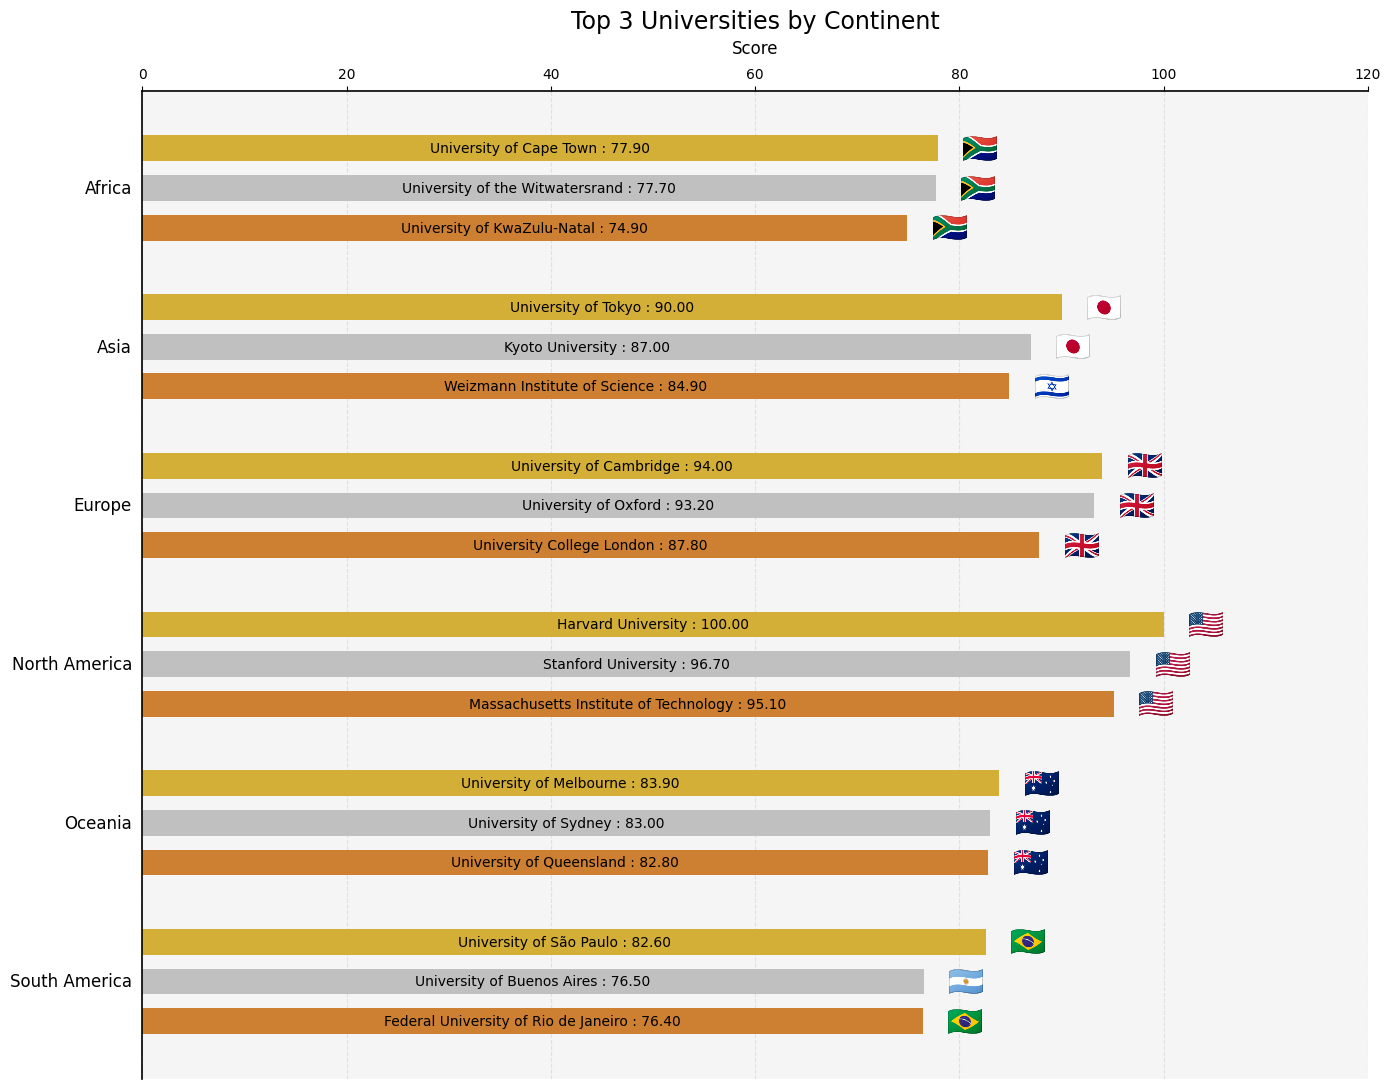

In [28]:
top_3["Continent Rank"] = (top_3.groupby("Continent")["World Rank"].rank(method="first").astype(int))

top_3 = top_3.sort_values(["Continent", "Continent Rank"]).reset_index(drop=True)


flag_urls = {
    "United States": "https://flagcdn.com/80x60/us.png",
    "United Kingdom": "https://flagcdn.com/80x60/gb.png",
    "Australia": "https://flagcdn.com/80x60/au.png",
    "Japan": "https://flagcdn.com/80x60/jp.png",
    "Brazil": "https://flagcdn.com/80x60/br.png",
    "Argentina":"https://flagcdn.com/80x60/ar.png",
    "Canada":"https://flagcdn.com/80x60/ca.png",
    "Israel": "https://flagcdn.com/80x60/il.png",
    "South Africa": "https://flagcdn.com/80x60/za.png",
}

# create y positions

continents = top_3["Continent"].unique()

y_positions = []
continent_centers = {}
current_y = 0

for continent in continents:
    positions = [current_y,current_y + 1,current_y + 2]
    y_positions.extend(positions)
    continent_centers[continent] = current_y + 1
    # space between continents
    current_y += 4

top_3["y"] = y_positions

# plot
fig, ax = plt.subplots(figsize=(14, 11))

# a very light whight so Japan flag is visible
ax.set_facecolor("#F5F5F5")

medal_colors = {
    1: "#D4AF37",   # Gold
    2: "#C0C0C0",   # Silver
    3: "#CD7F32"    # Bronze
}


#draw bars
for _, row in top_3.iterrows():

    ax.barh(
        row["y"],
        row["Score"],
        height=0.65,
        color=medal_colors[row["Continent Rank"]],
        edgecolor="none"
    )


#Add university name + score
for _, row in top_3.iterrows():

    score = row["Score"]
    y = row["y"]

    # Center of the bar
    x = score / 2

    ax.text(
        x,
        y,
        f"{row['Institution']} : {score:.2f}",
        ha="center",
        va="center",
        fontsize=10
    )

# Add actual flag images AFTER the bar
max_score = top_3["Score"].max()

for _, row in top_3.iterrows():

    country = row["Location"]

    if country not in flag_urls:
        continue

    url = flag_urls[country]
    response = requests.get(url)
    flag_image = Image.open(
        BytesIO(response.content)
    ).convert("RGBA")

    image = OffsetImage(
        flag_image,
        zoom=0.30
    )

    # Position after the bar
    x_flag = row["Score"] + max_score * 0.025

    annotation = AnnotationBbox(
        image,
        (x_flag, row["y"]),
        frameon=False,
        box_alignment=(0, 0.5)
    )

    ax.add_artist(annotation)


# 11. Add continent labels
for continent, y in continent_centers.items():

    ax.text(
        -1,
        y,
        continent,
        ha="right",
        va="center",
        fontsize=12,
        # fontweight="bold"
    )



# Keep y-axis visible
ax.set_yticks([])

ax.spines["left"].set_visible(True)
ax.spines["left"].set_linewidth(1.2)

ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)



ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

ax.set_xlabel(
    "Score",
    fontsize=12,
    labelpad=10
)

ax.spines["top"].set_visible(True)
ax.spines["top"].set_linewidth(1.2)


ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.set_title(
    "Top 3 Universities by Continent",
    fontsize=17,
    # fontweight="bold",
    pad=45
)


ax.invert_yaxis()
ax.set_xlim(0,120)
plt.tight_layout()

plt.show()

### Investigating the correlation between features and Instituition world rank
In the plot below, we see that only the feature `Score` has a **negative** correlation with `World Rank`.(The more the score, the better the university).
For other numeric features, starting from `National Rank` to `Citataions`, we observe **positive** correlation with world rank. (The more of that feature, the higher the work rank thus worse university). This is **contradictory** with the feature names. We should treat these features NOT like score, but like ranks.

For example:
Higher influence -> worse university
Lower Quality Publications -> better university


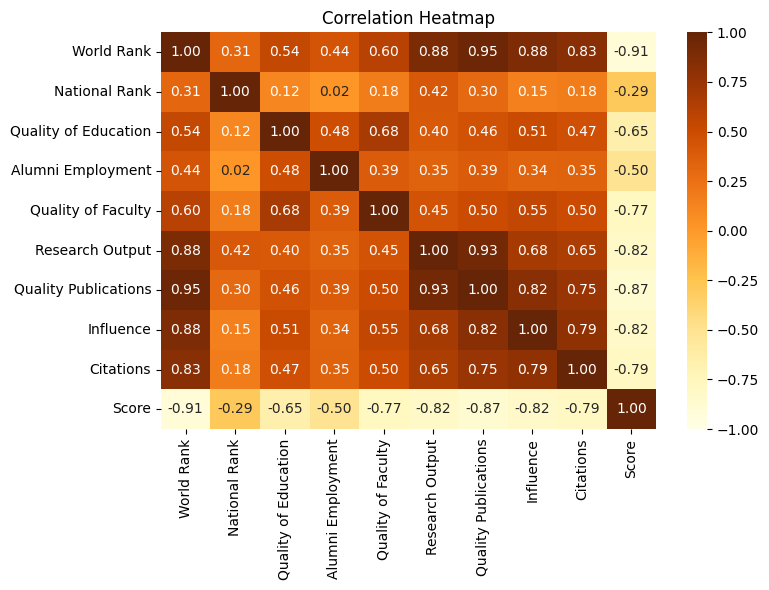

In [29]:
numeric_features =["World Rank",
"National Rank",
"Quality\xa0of Education",
"Alumni Employment",
"Quality\xa0of Faculty",
"Research Output",
"Quality Publications",
"Influence",
"Citations",
"Score"
]

corr = df1[numeric_features].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr,annot=True,fmt=".2f",cmap="YlOrBr",vmin=-1,vmax=1,center=0)
# "YlOrBr"
#"coolwarm"

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Investigation of numeric features (the ones that have a positive correlation with Worl Rank)

In [30]:
colors = {
    "gold": "#D4AF37",   
    "silver": "#C0C0C0", 
    "bornze": "#CD7F32", 
    "bg": "#F5F5F5",
    "grid1": "#D9D9D9",
    "grid-better": "white",
}

ranking_features = [
    "Quality\xa0of Education",
    "Alumni Employment",
    "Quality\xa0of Faculty",
    "Research Output",
    "Quality Publications",
    "Influence",
    "Citations"
]

# calculation of country level statistics
country_summary = (
    df1
    .groupby("Location")
    .agg(
        Institution_Count=("Institution", "count"),
        Average_Score=("Score", "mean"),
        Average_World_Rank=("World Rank", "mean"),
        **{
            feature: (feature, "mean")
            for feature in ranking_features
        }
    )
    .reset_index()
)

# sort countries from better to worse based on average world rank
country_summary = country_summary.sort_values("Average_World_Rank").reset_index(drop=True)


# subplot
fig = make_subplots(
    rows=len(ranking_features),
    cols=1,
    shared_xaxes=False,
    vertical_spacing=0.07,
    # subplot_titles=ranking_features
)


# onw line plot for each feature
for i, feature in enumerate(ranking_features, start=1):

    fig.add_trace(
        go.Scatter(
            x=country_summary["Location"],
            y=country_summary[feature],

            mode="lines+markers",

            customdata=country_summary[
                [
                    "Institution_Count",
                    "Average_Score",
                    "Average_World_Rank"
                ]
            ],

            hovertemplate=(
                "<b>%{x}</b><br><br>"
                "Number of Universities: %{customdata[0]}<br>"
                 "Average World Rank: %{customdata[2]:.2f}<br>"
                "Average Score: %{customdata[1]:.2f}<br>"
                f"Average {feature}: %{{y:.2f}}"
                "<extra></extra>"
            ),

            marker=dict(
                color = colors["gold"],
                size=7
            ),

            line=dict(
                color = colors["bornze"],
                width=2
            ),

            showlegend=False
        ),

        row=i,
        col=1
    )

   

# x axis on top, y inverted
for i, feature in enumerate(ranking_features, start=1):

    fig.update_xaxes(
        side="top",
        showticklabels=True,
        tickangle=-45,
        showgrid=False,
        row=i,
        col=1,
        title_text = "Countires Sorted by World Rank",
       
        showline=True,
        linewidth=1.5,
        linecolor="black",
        title_font=dict(
        size=14,
        # family="Arial Black",
        weight = "bold")
    )

    fig.update_yaxes(
        autorange="reversed",
        title_text=f"Average {feature}",
        gridcolor=colors["grid-better"],
        row=i,
        col=1,
      
        showline=True,
        linewidth=1.5,
        linecolor="black",
        
        title_font=dict(
        size=14,
        # family="Arial Black",
        weight = "bold")
    )
    
# improve layout
fig.update_layout(
    title=dict(
        text="Average University Performance by Country",
        x=0.5,
        y= 0.99,
        xanchor="center",
        font=dict(size=24)
    ),

    height=2500,
    width=1400,
    
    paper_bgcolor="white",
    plot_bgcolor=colors["bg"],


    hovermode="closest",

    margin=dict(
        t=220,
        b=50,
        l=80,
        r=50
    )
)

fig.show()

### Interpretation of the PLot

- Countries are ordered from lower to higher average World Rank from left to right on X axis.

- Higher position on each chart  generally indicates better performance (higher score and usually lower rank).

- I have deliberately used **x axis on top** and **inverted y axis** to better demonstrate the downward flow as the worl ranking increases.

#### Comparision of the first 3 plots with the  following 4 plots:
 - The first 3 plots (`Quality of  Education`, `Alumni Employment` and `Quality of Faculty`), do not show a distinct downward flow, and we expect them to be so because though their correlations with `World Rank` is positive, it has lower values (0.54 , 0.44, 0.6). However, the plots of `Research Output`, `Quality Publications`,`Influence`,`Citations` demonstrate the **downward** flow perfectly as they have higher correlations with `World Rank`. (0.88, 0.95 , 0.88, 0.83).

 - **Russia and Lebanan** have the best performance in terms of `Quality of  Education`, yet they do not have noticable World ranking.**Lebanan** also is the best country in terms of `Alumni Employment`.
 - **Switzerlad**, holding the 4th rank in average university world ranking, beats all other countiries **noticably** in terms of `Quality of Faculty`.
 - **Singapore**, being the top country with the best average university ranking, holds this position as it is the top country in terms of `Research Output`, `Quality Publications`,`Influence`,`Citations`.





### Percentage of countries in Top 1000 Universities
- In the plot below, You can see the percetage of Instituitions belonging to each country, for the range of world rank chosen.

In [31]:
rank_slider = widgets.IntRangeSlider(
    value=[1, 100],
    min=1,
    max=int(df1["World Rank"].max()),
    step=1,
    description="World Rank:",
    continuous_update=False,
    layout=widgets.Layout(width="700px")
)


def update_pie(rank_range):

    min_rank, max_rank = rank_range

    filtered_df = df1[
        df1["World Rank"].between(min_rank, max_rank)
    ]

    country_counts = (
        filtered_df["Location"]
        .value_counts()
        .reset_index()
    )

    country_counts.columns = [
        "Location",
        "Institution Count"
    ]

    fig = px.pie(
        country_counts,
        values="Institution Count",
        names="Location",
        title=f"Country Distribution of Universities<br>"
              f"World Rank: {min_rank}–{max_rank}"
    )

    fig.update_traces(
        textinfo="percent",
        textposition="inside"
    )

    fig.update_layout(
        legend_title="Country",
        width=1000,
        height=750
    )

    fig.show()
    
    
widgets.interact(update_pie, rank_range=rank_slider)

interactive(children=(IntRangeSlider(value=(1, 100), continuous_update=False, description='World Rank:', layou…

<function __main__.update_pie(rank_range)>

### Research vs Emloyment Among Top 50 Universities of the World


C:\Users\Nassrin Sharifi\AppData\Local\Temp\ipykernel_16408\3665258260.py:190: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Nassrin Sharifi\.conda\envs\EDA-py311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


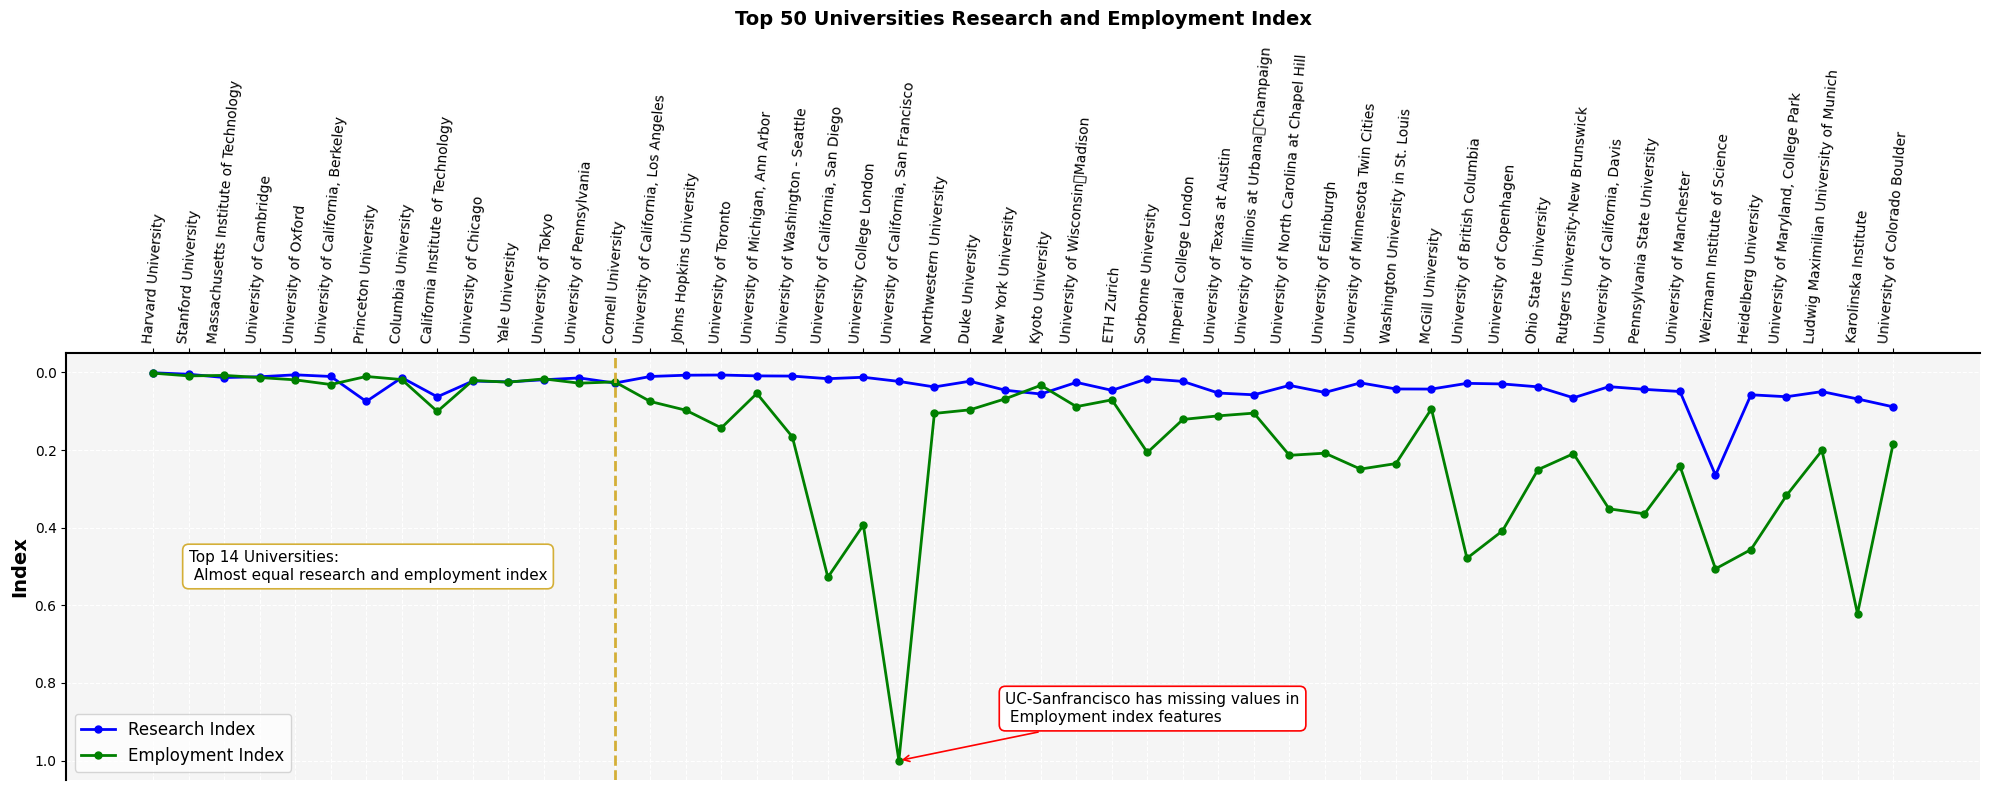

In [71]:
research_features = [
    "Research Output",
    "Quality Publications",
    "Influence",
    "Citations"
]

employment_features = [
    "Quality\xa0of Education",
    "Alumni Employment"
]

#Normalize
df_index = df1.copy()

all_index_features = research_features + employment_features

for feature in all_index_features:
    df_index[feature + "_normalized"] = (
        df_index[feature] / df_index[feature].max() # divide each feature by the max value of it in the whole dataset.
    )
    

# calculation of Indexes : sum of normalizes features / number of features within each Index
        
research_normalized = [
    feature + "_normalized"
    for feature in research_features
]

df_index["Research Index"] = (
    df_index[research_normalized].sum(axis=1)
    / len(research_features)
)

employment_normalized = [
    feature + "_normalized"
    for feature in employment_features
]

df_index["Employment Index"] = (
    df_index[employment_normalized].sum(axis=1)
    / len(employment_features)
)

# plot for top 50
top_50 = (df_index.sort_values("World Rank").head(50).copy())


fig, ax = plt.subplots(figsize=(20, 8))

# Research Index
ax.plot(
    top_50["Institution"],
    top_50["Research Index"],
    marker="o",
    linewidth=2,
    markersize=5,
    label="Research Index",
    color="blue"
)

# Employment Index
ax.plot(
    top_50["Institution"],
    top_50["Employment Index"],
    marker="o",
    linewidth=2,
    markersize=5,
    label="Employment Index",
    color="green"
)

# Y-axis
ax.set_ylabel(
    "Index",
    fontsize=14,
    fontweight="bold"
)

# Move x-axis to the top
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

ax.set_xlabel(
    "Top 50 Universities Research and Employment Index",
    fontsize=14,
    fontweight="bold",
    labelpad=15
)

# Rotate university names
ax.tick_params(
    axis="x",
    labelrotation=85,
    labelsize=10
)


# Find the x position of Cornell University
cornell_idx = top_50.index[top_50["Institution"] == "Cornell University"][0]

# Because the DataFrame index may not be 0, 1, 2, ... not needed herec cuz it is:)
cornell_pos = top_50.index.get_loc(cornell_idx)

ax.axvline(
    x=cornell_pos,
    color= colors["gold"],
    linestyle="--",
    linewidth=2
)


ax.text(
    cornell_pos - 12,
    0.5,
    "Top 14 Universities:\n Almost equal research and employment index",
    ha="left",
    va="center",
    fontsize=11,

    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor=colors["gold"],
        linewidth=1.2
    )
)


# anotation

sanfrancisco_pos = top_50.index[top_50["Institution"] ==  "University of California, San Francisco"][0]
ax.annotate(
    "UC-Sanfrancisco has missing values in\n Employment index features",

    xy=(sanfrancisco_pos, 1),

    # Put annotation box to the right of the point
    xytext=(sanfrancisco_pos + 3, 0.9),

    fontsize=11,

    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="red",
        linewidth=1.2
    ),

    arrowprops=dict(
        arrowstyle="->",
        color="red",
        linewidth=1.2
    )
)


# Make both axes visible
ax.spines["top"].set_visible(True)
ax.spines["left"].set_visible(True)

# Optional: hide the other two spines
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Make visible axis lines slightly thicker
ax.spines["top"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)


ax.invert_yaxis()

# Legend
ax.legend(
    fontsize=12,
    frameon=True
)

ax.set_facecolor(colors["bg"])

# Optional grid
ax.grid(
    # axis="y",
    linestyle="--",
    # alpha=0.4,
    color = colors["grid-better"]
)

plt.tight_layout()
plt.show()

### Interpretation of the Plot

#### Research Index:
$$
\text{Research Index}_i =
\frac{1}{4}
\left(
\frac{\text{Research ouput}_i}{\max(\text{Research ouput})}
+
\frac{\text{Quality of Publications}_i}{\max(\text{Quality of Publications})}
+
\frac{\text{Influence}_i}{\max(\text{Influence})}
+
\frac{\text{Citation}_i}{\max(\text{Citation})}
\right)
$$

#### Employment Index:


$$
\text{Employment Index}_i =
\frac{1}{2}
\left(
\frac{\text{Quality of Education}_i}{\max(\text{Quality of Education})}
+
\frac{\text{Alumni Employment}_i}{\max(\text{Alumni Employment})}
\right)
$$


- According to the plot above, Among the top 14 universities, there are almost the same research and employment oppurtunities. However, as the World rank increases after that, a gap is visible between indexes, demonstrating **universities are better suited for research than Employment**